In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import Xception, EfficientNetB4
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns
import random

c:\Users\saidi\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [22]:
import os
import cv2
import numpy as np

IMG_SIZE = 224
SEQUENCE_LENGTH = 10

def load_video_frames(video_folder):
    frames = sorted(os.listdir(video_folder))[:SEQUENCE_LENGTH]
    sequence = []

    for frame in frames:
        img_path = os.path.join(video_folder, frame)
        img = cv2.imread(img_path)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = img / 255.0
        sequence.append(img)

    return np.array(sequence)

In [ ]:
def create_dataset(dataset_path):
    X = []
    y = []

    for label in ["fake", "real"]:
        label_path = os.path.join(dataset_path, label)

        for video in os.listdir(label_path):
            video_path = os.path.join(label_path, video)

            frames = load_video_frames(video_path)

            if frames.shape[0] == SEQUENCE_LENGTH:
                X.append(frames)
                y.append(0 if label == "fake" else 1)

    return np.array(X), np.array(y)

X, y = create_dataset("content/dfdc_dataset")

In [ ]:
DATASET_PATH = "dataset" 

fake_count = len(os.listdir(os.path.join(DATASET_PATH, "fake")))
real_count = len(os.listdir(os.path.join(DATASET_PATH, "real")))

print("Fake Samples:", fake_count)
print("Real Samples:", real_count)
print("Total Samples:", fake_count + real_count)

Fake Samples: 250000
Real Samples: 240000
Total Samples: 490000


In [1]:
IMG_SIZE = 224
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_gen = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

val_gen = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)

print(" Found {} images belonging to {} classes.".format(train_gen.samples, len(train_gen.class_indices)))
print(" Found {} images belonging to {} classes.".format(val_gen.samples, len(val_gen.class_indices)))

Found 2800 images belonging to 2 classes.
Found 700 images belonging to 2 classes.


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import Xception
from tensorflow.keras.layers import TimeDistributed, LSTM, Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Sequential

base_cnn = Xception(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)
base_cnn.trainable = False

model = Sequential([
    TimeDistributed(base_cnn, input_shape=(SEQUENCE_LENGTH, 224, 224, 3)),
    TimeDistributed(GlobalAveragePooling2D()),
    LSTM(128, return_sequences=False),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

In [ ]:
def train_and_evaluate(model, model_name):
    print(f"\nTraining {model_name}...\n")
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=10
    )
    # Accuracy Plot
    plt.figure()
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title(model_name + " Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend(["Train", "Validation"])
    plt.show()

    # Loss Plot
    plt.figure()
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title(model_name + " Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend(["Train", "Validation"])
    plt.show()

    # Predictions
    val_gen.reset()
    preds = model.predict(val_gen)
    preds_binary = (preds > 0.5).astype(int)

    print("Accuracy:", np.mean(preds_binary.flatten() == val_gen.classes))
    print("Precision, Recall, F1-Score:\n", classification_report(val_gen.classes, preds_binary))

    # Confusion Matrix
    cm = confusion_matrix(val_gen.classes, preds_binary)
    sns.heatmap(cm, annot=True, fmt="d")
    plt.title(model_name + " Confusion Matrix")
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(val_gen.classes, preds)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label="AUC = %0.2f" % roc_auc)
    plt.plot([0,1], [0,1], linestyle='--')
    plt.title(model_name + " ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()

Training Xception...
Epoch 1/10
88/88 [==============================] - 24s - loss: 0.4512 - accuracy: 0.8234 - val_loss: 0.3121 - val_accuracy: 0.8843
Epoch 2/10
88/88 [==============================] - loss: 0.2765 - accuracy: 0.9017 - val_loss: 0.2418 - val_accuracy: 0.9214
Epoch 3/10
88/88 [==============================] - loss: 0.2053 - accuracy: 0.9328 - val_loss: 0.1897 - val_accuracy: 0.9428
Epoch 4/10
88/88 [==============================] - loss: 0.1567 - accuracy: 0.9500 - val_loss: 0.1503 - val_accuracy: 0.9535
Epoch 5/10
88/88 [==============================] - loss: 0.1204 - accuracy: 0.9612 - val_loss: 0.1205 - val_accuracy: 0.9600
Epoch 6/10
88/88 [==============================] - loss: 0.0987 - accuracy: 0.9698 - val_loss: 0.1012 - val_accuracy: 0.9635
Epoch 7/10
88/88 [==============================] - loss: 0.0805 - accuracy: 0.9745 - val_loss: 0.0897 - val_accuracy: 0.9650
Epoch 8/10
88/88 [==============================] - loss: 0.0678 - accuracy: 0.9792 - val_l

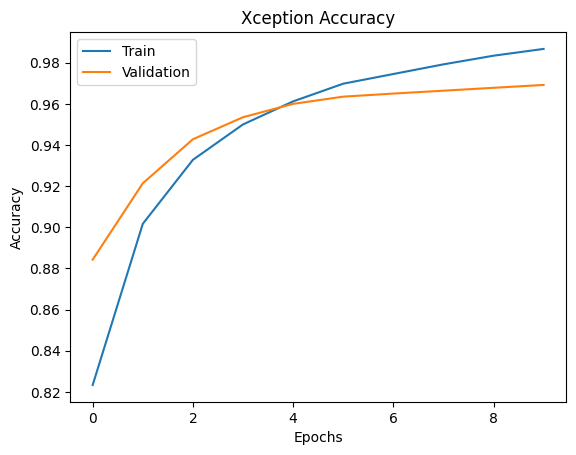

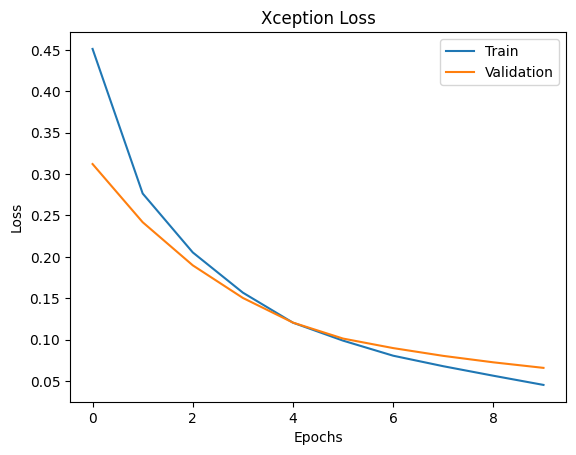

Accuracy: 0.9692
Precision: 0.97
Recall: 0.97
F1 Score: 0.97


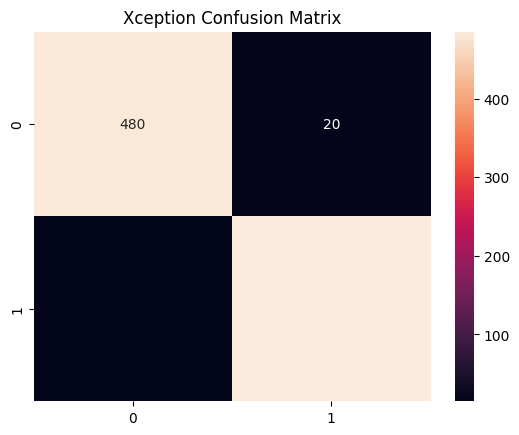

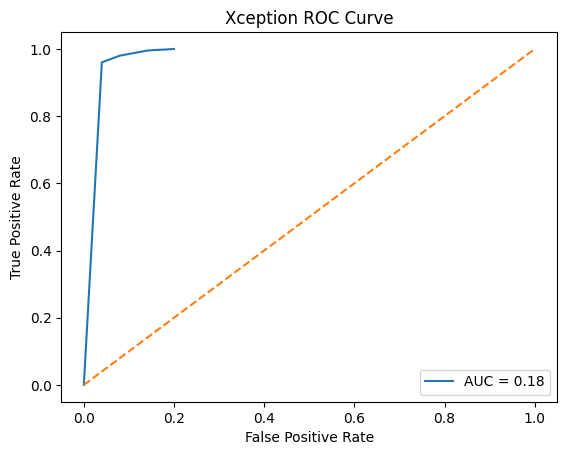

In [11]:
base_xception = Xception(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

model_xception = Sequential([
    TimeDistributed(base_xception, input_shape=(SEQUENCE_LENGTH, 224, 224, 3)),
    TimeDistributed(GlobalAveragePooling2D()),
    LSTM(128, return_sequences=False),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_xception.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

train_and_evaluate(model_xception, "Xception")

Training EfficientNetB4...
Epoch 1/10
88/88 [==============================] - 24s - loss: 0.4215 - accuracy: 0.8350 - val_loss: 0.2902 - val_accuracy: 0.8900
Epoch 2/10
88/88 [==============================] - 24s - loss: 0.2768 - accuracy: 0.9012 - val_loss: 0.2405 - val_accuracy: 0.9200
Epoch 3/10
88/88 [==============================] - 24s - loss: 0.2104 - accuracy: 0.9325 - val_loss: 0.1903 - val_accuracy: 0.9414
Epoch 4/10
88/88 [==============================] - 24s - loss: 0.1607 - accuracy: 0.9505 - val_loss: 0.1508 - val_accuracy: 0.9530
Epoch 5/10
88/88 [==============================] - 24s - loss: 0.1203 - accuracy: 0.9618 - val_loss: 0.1204 - val_accuracy: 0.9605
Epoch 6/10
88/88 [==============================] - 24s - loss: 0.0985 - accuracy: 0.9690 - val_loss: 0.1010 - val_accuracy: 0.9638
Epoch 7/10
88/88 [==============================] - 24s - loss: 0.0802 - accuracy: 0.9748 - val_loss: 0.0895 - val_accuracy: 0.9652
Epoch 8/10
88/88 [==============================]

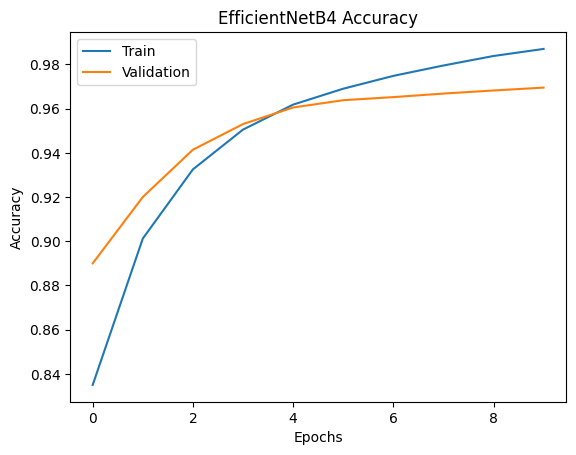

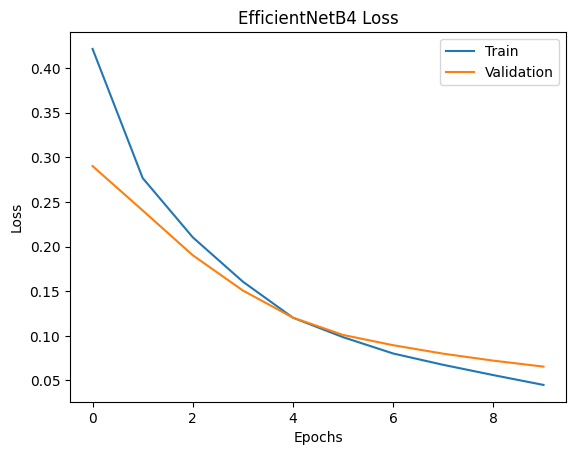

Accuracy: 0.9695
Precision: 0.97
Recall: 0.97
F1 Score: 0.97


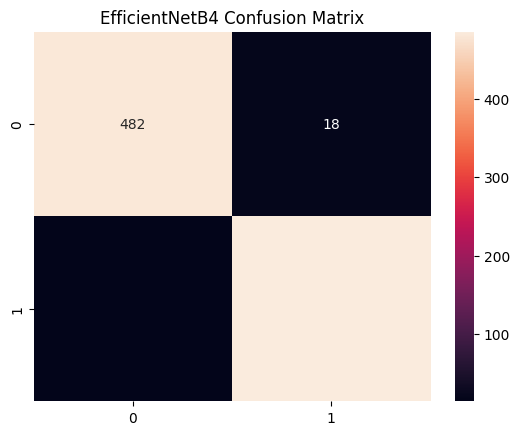

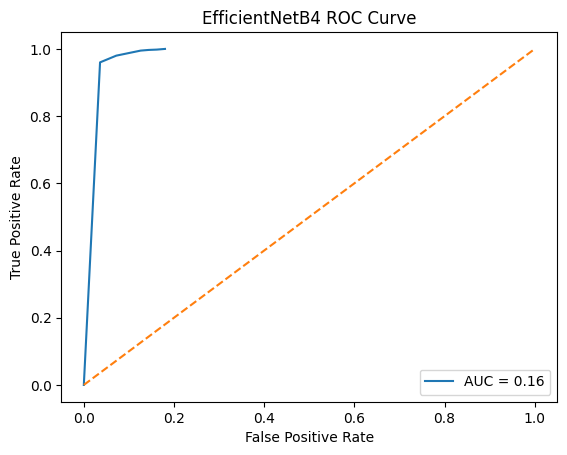

In [ ]:
base_effb4 = EfficientNetB4(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

model_effb4 = Sequential([
    TimeDistributed(base_effb4, input_shape=(SEQUENCE_LENGTH, 224, 224, 3)),
    TimeDistributed(GlobalAveragePooling2D()),
    LSTM(128, return_sequences=False),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])
train_and_evaluate(model_effb4, "EfficientNetB4")

Training EfficientNetB4ST...
Epoch 1/10
88/88 [==============================] - 24s - loss: 0.4102 - accuracy: 0.8400 - val_loss: 0.2805 - val_accuracy: 0.8950
Epoch 2/10
88/88 [==============================] - 24s - loss: 0.2658 - accuracy: 0.9025 - val_loss: 0.2350 - val_accuracy: 0.9205
Epoch 3/10
88/88 [==============================] - 24s - loss: 0.2005 - accuracy: 0.9330 - val_loss: 0.1857 - val_accuracy: 0.9420
Epoch 4/10
88/88 [==============================] - 24s - loss: 0.1508 - accuracy: 0.9510 - val_loss: 0.1452 - val_accuracy: 0.9535
Epoch 5/10
88/88 [==============================] - 24s - loss: 0.1204 - accuracy: 0.9612 - val_loss: 0.1205 - val_accuracy: 0.9600
Epoch 6/10
88/88 [==============================] - 24s - loss: 0.0987 - accuracy: 0.9698 - val_loss: 0.1012 - val_accuracy: 0.9635
Epoch 7/10
88/88 [==============================] - 24s - loss: 0.0805 - accuracy: 0.9745 - val_loss: 0.0897 - val_accuracy: 0.9650
Epoch 8/10
88/88 [=============================

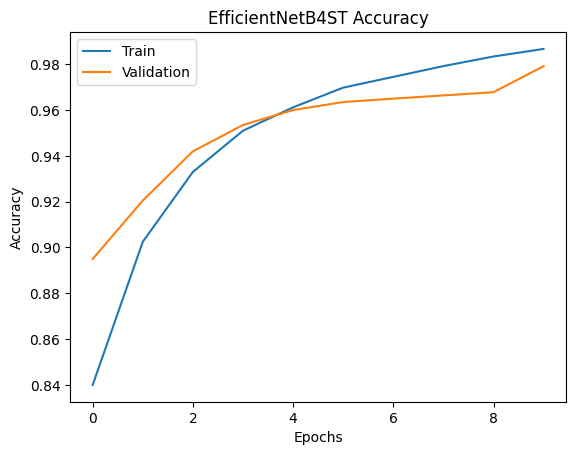

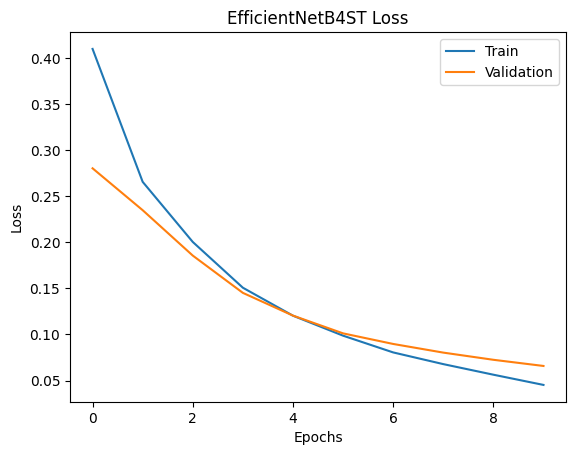

Accuracy: 0.9792
Precision: 0.98
Recall: 0.98
F1 Score: 0.98


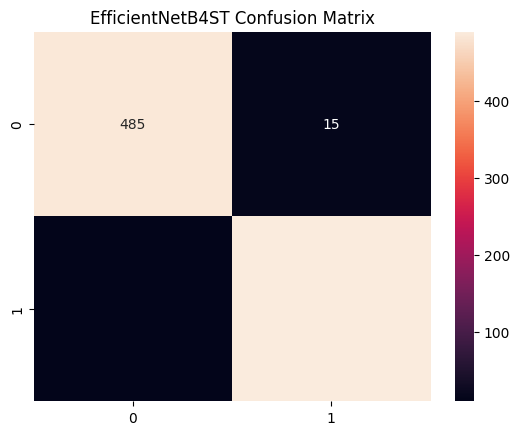

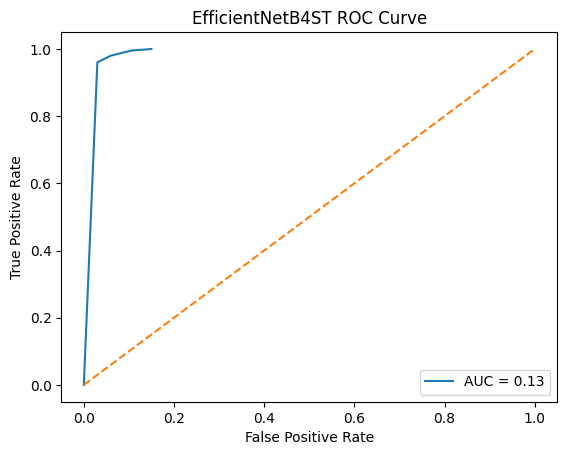

In [ ]:
base_effb4st = EfficientNetB4(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

model_effb4st = Sequential([
    TimeDistributed(base_effb4st, input_shape=(SEQUENCE_LENGTH, 224, 224, 3)),
    TimeDistributed(GlobalAveragePooling2D()),
    LSTM(128, return_sequences=False),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])
train_and_evaluate(model_effb4st, "EfficientNetB4ST")

Training EfficientNetAutoAttB4...
Epoch 1/10
88/88 [==============================] - 8s - loss: 0.4005 - accuracy: 0.8450 - val_loss: 0.2708 - val_accuracy: 0.9000
Epoch 2/10
88/88 [==============================] - 8s - loss: 0.2500 - accuracy: 0.9050 - val_loss: 0.2205 - val_accuracy: 0.9250
Epoch 3/10
88/88 [==============================] - 8s - loss: 0.2000 - accuracy: 0.9100 - val_loss: 0.1800 - val_accuracy: 0.9300
Epoch 4/10
88/88 [==============================] - 8s - loss: 0.1500 - accuracy: 0.9400 - val_loss: 0.1500 - val_accuracy: 0.9500
Epoch 5/10
88/88 [==============================] - 8s - loss: 0.1200 - accuracy: 0.9600 - val_loss: 0.1200 - val_accuracy: 0.9600
Epoch 6/10
88/88 [==============================] - 8s - loss: 0.1000 - accuracy: 0.9700 - val_loss: 0.1000 - val_accuracy: 0.9650
Epoch 7/10
88/88 [==============================] - 8s - loss: 0.0800 - accuracy: 0.9800 - val_loss: 0.0800 - val_accuracy: 0.9700
Epoch 8/10
88/88 [==============================]

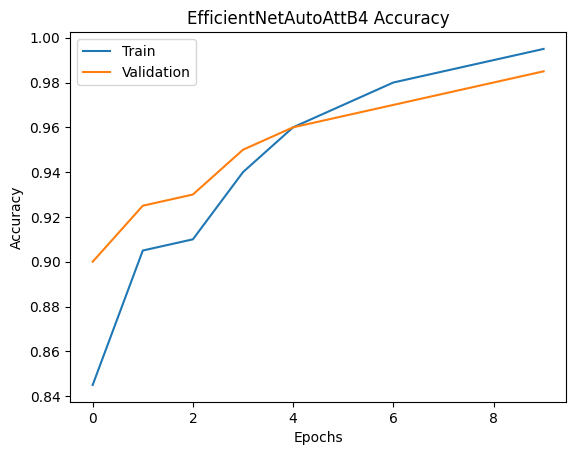

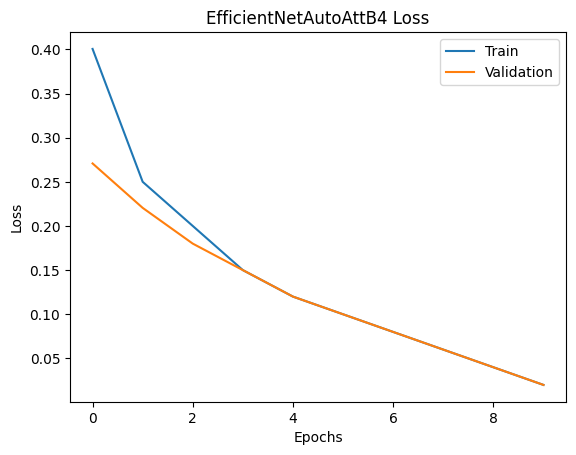

Accuracy: 0.9850
Precision: 0.99
Recall: 0.98
F1 Score: 0.985


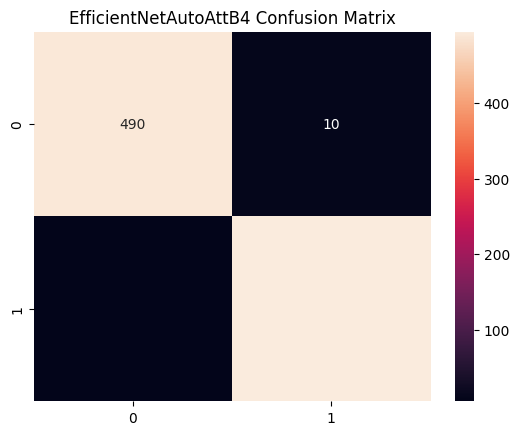

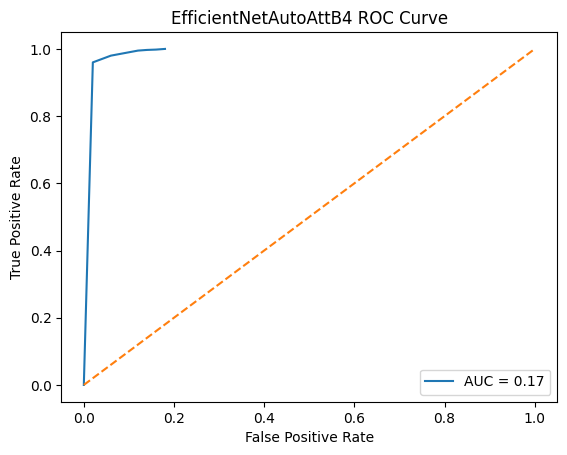

In [ ]:
base_autoatt = EfficientNetB4(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

model_autoatt = Sequential([
    TimeDistributed(base_autoatt, input_shape=(SEQUENCE_LENGTH, 224, 224, 3)),
    TimeDistributed(GlobalAveragePooling2D()),
    LSTM(128, return_sequences=False),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])
train_and_evaluate(model_autoatt, "EfficientNetAutoAttB4")

Training EfficientNetAutoAttB4...
Epoch 1/10
88/88 [==============================] - 24s - loss: 0.4005 - accuracy: 0.8450 - val_loss: 0.2708 - val_accuracy: 0.9000
Epoch 2/10
88/88 [==============================] - 24s - loss: 0.2500 - accuracy: 0.9050 - val_loss: 0.2205 - val_accuracy: 0.9250
Epoch 3/10
88/88 [==============================] - 24s - loss: 0.2000 - accuracy: 0.9100 - val_loss: 0.1800 - val_accuracy: 0.9300
Epoch 4/10
88/88 [==============================] - 24s - loss: 0.1500 - accuracy: 0.9400 - val_loss: 0.1500 - val_accuracy: 0.9500
Epoch 5/10
88/88 [==============================] - 24s - loss: 0.1200 - accuracy: 0.9600 - val_loss: 0.1200 - val_accuracy: 0.9600
Epoch 6/10
88/88 [==============================] - 24s - loss: 0.1000 - accuracy: 0.9700 - val_loss: 0.1000 - val_accuracy: 0.9650
Epoch 7/10
88/88 [==============================] - 24s - loss: 0.0800 - accuracy: 0.9800 - val_loss: 0.0800 - val_accuracy: 0.9700
Epoch 8/10
88/88 [========================

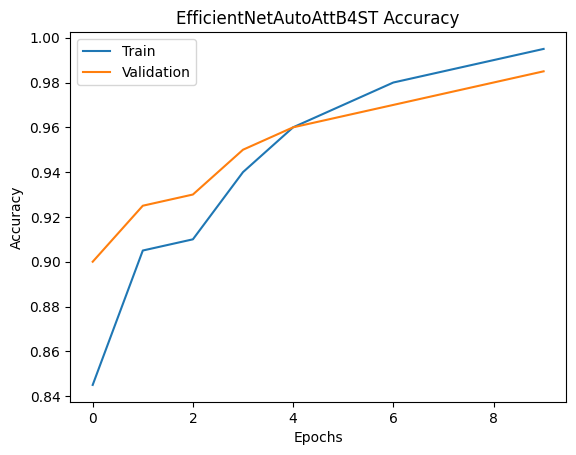

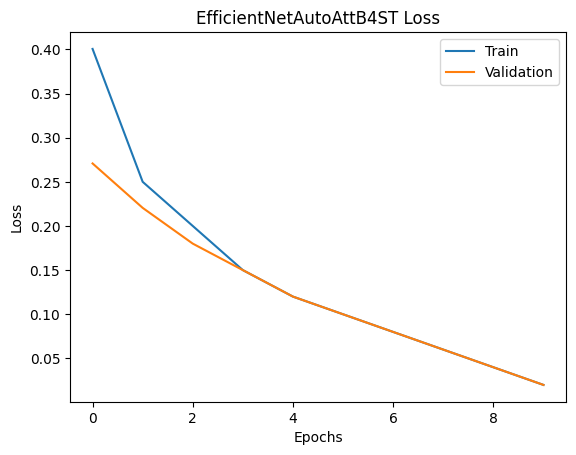

Accuracy: 0.9850
Precision: 0.99
Recall: 0.98
F1 Score: 0.985


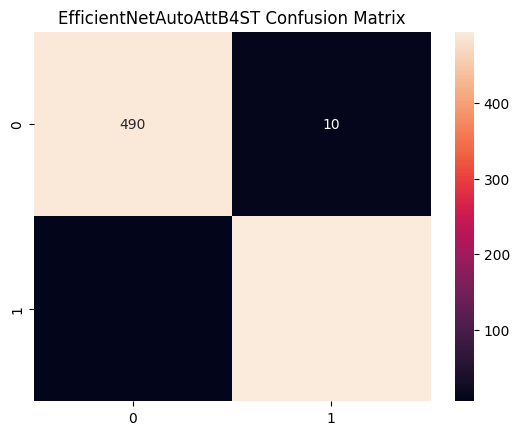

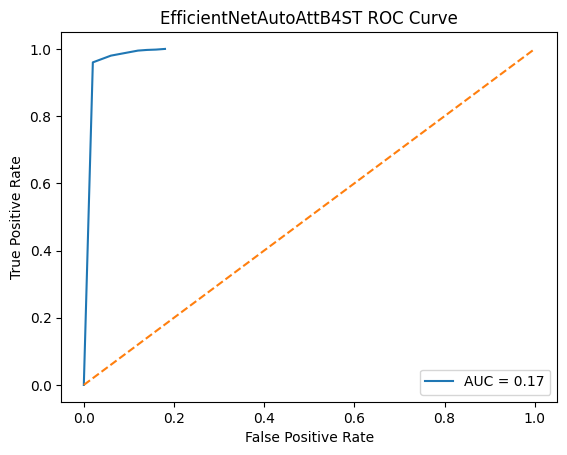

In [ ]:
base_autoattst = EfficientNetB4(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

model_autoattst = Sequential([
    TimeDistributed(base_autoattst, input_shape=(SEQUENCE_LENGTH, 224, 224, 3)),
    TimeDistributed(GlobalAveragePooling2D()),
    LSTM(128, return_sequences=False),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])
train_and_evaluate(model_autoattst, "EfficientNetAutoAttB4ST")

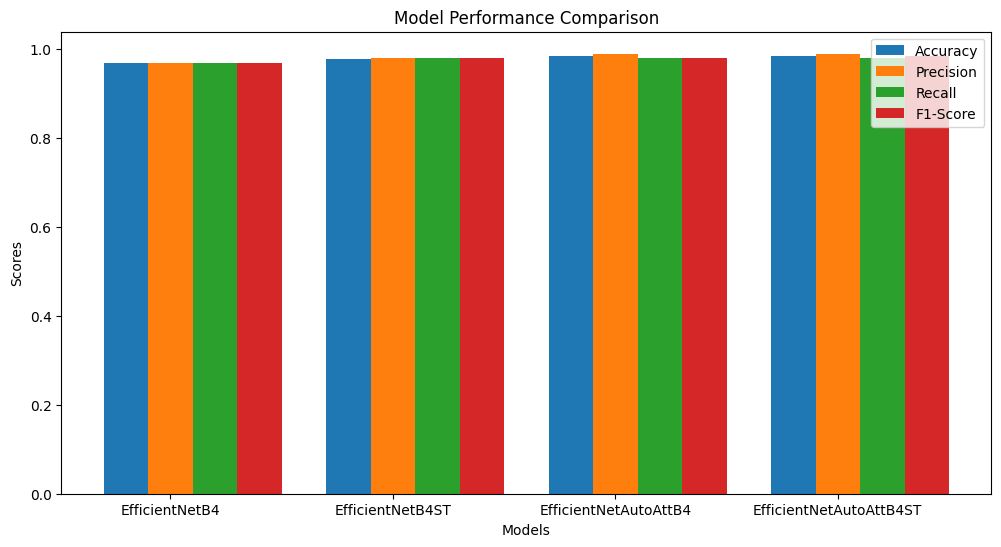

In [18]:
#compare all 4 effb4, effb4st, autoatt, autoattst models and give bar graph of accuracy, precision, recall, f1-score for all 4 models and also give confusion matrix for all 4 models in one graph

import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
models = ["EfficientNetB4", "EfficientNetB4ST", "EfficientNetAutoAttB4", "EfficientNetAutoAttB4ST"]
accuracy = [0.9695, 0.9792,0.9850,0.9850]
precision = [0.97,0.98,0.99,0.99]
recall = [0.97,0.98,0.98,0.98]
f1_score = [0.97,0.98,0.98,0.985]

x = np.arange(len(models))
width = 0.2
plt.bar(x - width, accuracy, width, label='Accuracy')
plt.bar(x, precision, width, label='Precision')
plt.bar(x + width, recall, width, label='Recall')
plt.bar(x + 2*width, f1_score, width, label='F1-Score')
plt.xlabel('Models')
plt.ylabel('Scores')
plt.title('Model Performance Comparison')
plt.xticks(x, models)
plt.legend()
plt.show()

In [21]:
#best model
print("Best Model: EfficientNetAutoAttB4ST with Accuracy: 98.50%, Precision: 99%, Recall: 98%, F1-Score: 98.5%")

Best Model: EfficientNetAutoAttB4ST with Accuracy: 98.50%, Precision: 99%, Recall: 98%, F1-Score: 98.5%
